# Bandidos Multi-Brazo en el Sector Salud

En este notebook, exploraremos cómo aplicar el problema de los **Bandidos Multi-Brazo (Multi-Armed Bandits)** para optimizar tratamientos médicos. 

## El Caso: Optimización de Tratamientos

Imagina que eres un médico o un sistema de IA encargado de asignar tratamientos a pacientes que llegan con una enfermedad específica. Tienes a tu disposición 5 tratamientos diferentes (Tratamiento A, B, C, D, E), pero no sabes cuál es la probabilidad real de éxito de cada uno. 

**Tu objetivo** es curar a la mayor cantidad posible de pacientes a lo largo del tiempo. Esto plantea un dilema clásico:

- **Exploración**: Probar tratamientos sobre los que tienes poca información para ver si son mejores de lo que crees.
- **Explotación**: Usar el tratamiento que, hasta ahora, ha demostrado ser el mejor para asegurar la cura del paciente actual.

Implementaremos y compararemos diferentes agentes para resolver este problema.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 1. El Entorno (Environment)

Definimos una clase base `Environment` y una clase específica `HealthEnvironment` que simula nuestro escenario médico.

In [2]:
class Environment:
    def __init__(self):
        self.steps_left = 0

    def is_done(self) -> bool:
        return self.steps_left == 0

    def get_observation(self) -> list:
        raise NotImplementedError

    def get_actions(self) -> list:
        raise NotImplementedError

    def action(self, action: int) -> float:
        raise NotImplementedError

class HealthEnvironment(Environment):
    def __init__(self, p_success, steps=1000):
        self.p_success = p_success  # Probabilidades reales de cura (desconocidas para el agente)
        self.steps_left = steps
        self.n_actions = len(p_success)

    def is_done(self) -> bool:
        return self.steps_left == 0

    def get_observation(self) -> list:
        # En el problema de bandidos clásico, el estado es constante o irrelevante para la toma de decisiones inmediata
        return [0.0, 0.0, 0.0]

    def get_actions(self) -> list:
        return list(range(self.n_actions))

    def action(self, action: int) -> float:
        if self.is_done():
            raise Exception("Game is over")
        
        self.steps_left -= 1
        
        # Simulamos el resultado del tratamiento (1: Cura, 0: No cura)
        # Usamos random.random() < p para simular la probabilidad de éxito
        if np.random.random() < self.p_success[action]:
            return 1.0
        else:
            return 0.0

## 2. Definición del Agente

Creamos una clase base `Agent` que define la estructura común para todos nuestros algoritmos.

In [3]:
class Agent:
    def __init__(self, verbose=False):
        self.total_reward = 0.0
        self.steps_rewards = []
        self.actions = []
        self.verbose = verbose

    def reset(self):
        self.total_reward = 0.0
        self.steps_rewards = []
        self.actions = []

    def choose_action(self, action_space: list) -> int:
        raise NotImplementedError

    def update(self, action: int, reward: float):
        # Método para que el agente aprenda de la experiencia (opcional/sobreescribible)
        pass

    def step(self, env: Environment):
        obs = env.get_observation()
        possible_actions = env.get_actions()
        
        action = self.choose_action(possible_actions)
        reward = env.action(action)
        
        self.update(action, reward)
        
        self.total_reward += reward
        self.steps_rewards.append(reward)
        self.actions.append(action)
        
        if self.verbose:
            print(f"Obs: {obs}, Action: {action}, Reward: {reward}")

## 3. Implementación de Agentes

Ahora implementaremos diferentes estrategias.

### 3.1 Agente Aleatorio
Simplemente elige un tratamiento al azar en cada paso. Nos sirve como línea base para comparar.

In [4]:
class RandomAgent(Agent):
    def choose_action(self, action_space: list) -> int:
        return np.random.choice(action_space)

### 3.2 Agente Epsilon-Greedy
Con probabilidad `epsilon`, explora (elige al azar). Con probabilidad `1 - epsilon`, explota (elige la mejor acción conocida).

In [5]:
class EpsilonGreedyAgent(Agent):
    def __init__(self, epsilon=0.1, n_actions=5, verbose=False):
        super().__init__(verbose)
        self.epsilon = epsilon
        self.n_actions = n_actions
        self.q_values = np.zeros(n_actions)
        self.arm_counts = np.zeros(n_actions)

    def reset(self):
        super().reset()
        self.q_values = np.zeros(self.n_actions)
        self.arm_counts = np.zeros(self.n_actions)

    def choose_action(self, action_space: list) -> int:
        if np.random.random() < self.epsilon:
            return np.random.choice(action_space)
        else:
            # Romper empates aleatoriamente
            max_q = np.max(self.q_values)
            best_actions = [a for a in action_space if self.q_values[a] == max_q]
            return np.random.choice(best_actions)

    def update(self, action: int, reward: float):
        self.arm_counts[action] += 1
        # Actualización incremental de la media (Q-value)
        self.q_values[action] += (reward - self.q_values[action]) / self.arm_counts[action]

### 3.3 Agente Softmax (Boltzmann)
Elige acciones probabilísticamente basándose en sus valores estimados. Acciones con mayor valor tienen mayor probabilidad, controlada por la temperatura `tau`.

In [6]:
class SoftmaxAgent(Agent):
    def __init__(self, temperature=1.0, n_actions=5, verbose=False):
        super().__init__(verbose)
        self.temperature = temperature
        self.n_actions = n_actions
        self.q_values = np.zeros(n_actions)
        self.arm_counts = np.zeros(n_actions)

    def reset(self):
        super().reset()
        self.q_values = np.zeros(self.n_actions)
        self.arm_counts = np.zeros(self.n_actions)

    def softmax(self, x):
        # Sustraer max para estabilidad numérica
        e_x = np.exp((x - np.max(x)) / self.temperature)
        return e_x / e_x.sum()

    def choose_action(self, action_space: list) -> int:
        probs = self.softmax(self.q_values)
        # Asegurar que las probabilidades sumen 1 (por errores de punto flotante)
        probs = probs / np.sum(probs)
        return np.random.choice(action_space, p=probs)

    def update(self, action: int, reward: float):
        self.arm_counts[action] += 1
        self.q_values[action] += (reward - self.q_values[action]) / self.arm_counts[action]

### 3.4 Agente Policy Gradient
Aprende una preferencia numérica para cada acción. No estima valores de recompensa directamente, sino que sube el gradiente de la recompensa esperada.

In [7]:
class PolicyGradientAgent(Agent):
    def __init__(self, alpha=0.1, n_actions=5, verbose=False):
        super().__init__(verbose)
        self.alpha = alpha
        self.n_actions = n_actions
        self.preferences = np.zeros(n_actions)
        self.avg_reward = 0.0
        self.time_step = 0
        self.last_probs = None # Para guardar las probabilidades calculadas en choose_action

    def reset(self):
        super().reset()
        self.preferences = np.zeros(self.n_actions)
        self.avg_reward = 0.0
        self.time_step = 0
        self.last_probs = None

    def softmax(self, x):
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum()

    def choose_action(self, action_space: list) -> int:
        self.last_probs = self.softmax(self.preferences)
        return np.random.choice(action_space, p=self.last_probs)

    def update(self, action: int, reward: float):
        self.time_step += 1
        # Actualizar average reward (baseline)
        self.avg_reward += (reward - self.avg_reward) / self.time_step
        
        one_hot = np.zeros(self.n_actions)
        one_hot[action] = 1
        
        # Actualizar preferencias
        # H[a] = H[a] + alpha * (R - R_avg) * (1 - pi[a])  si a == A_t
        # H[b] = H[b] - alpha * (R - R_avg) * pi[b]        si b != A_t
        # Esto se simplifica vectorialmente:
        self.preferences += self.alpha * (reward - self.avg_reward) * (one_hot - self.last_probs)

## 4. Comparación y Resultados

Ejecutamos simulaciones para comparar el desempeño de los agentes. Usaremos un escenario donde hay 5 tratamientos con diferentes tasas de éxito.

In [8]:
# Configuración del Experimento
true_probs = [0.1, 0.5, 0.8, 0.2, 0.3] # El Tratamiento 2 (índice 2) es el mejor (80% éxito)
n_steps = 1000
n_experiments = 100 # Promediamos sobre varios experimentos para suavizar las curvas

agents = {
    "Aleatorio": RandomAgent(),
    "Epsilon-Greedy (eps=0.1)": EpsilonGreedyAgent(epsilon=0.1, n_actions=5),
    "Softmax (temp=0.5)": SoftmaxAgent(temperature=0.5, n_actions=5),
    "Policy Gradient (alpha=0.1)": PolicyGradientAgent(alpha=0.1, n_actions=5)
}

results = {name: np.zeros(n_steps) for name in agents.keys()}
regrets = {name: np.zeros(n_steps) for name in agents.keys()}
optimal_action_counts = {name: np.zeros(n_steps) for name in agents.keys()}
optimal_action_idx = np.argmax(true_probs)

print(f"Iniciando simulaciones con probabilidades reales: {true_probs}")
print(f"El mejor tratamiento es el índice {optimal_action_idx} ({true_probs[optimal_action_idx]*100}% éxito)")

for name, agent in agents.items():
    for _ in range(n_experiments):
        env = HealthEnvironment(true_probs, steps=n_steps)
        agent.reset()
        
        temp_rewards = []
        temp_optimal = []
        
        while not env.is_done():
            obs = env.get_observation()
            # Hack: sabemos el estado interno del agente para trackear optimal actions
            # pero el 'step' ya hace todo. Solo necesitamos saber qué accion tomó.
            # Como step modifica el estado, necesitamos hacerlo paso a paso manualmente o confiar en el historial
            # Para simplificar y usar la estructura agent.step(env), modificaremos ligeramente la lógica de recolección
            
            agent.step(env)
        
        # Acumular resultados
        results[name] += np.array(agent.steps_rewards)
        
        # Calcular Regret Acumulado empírico: max_prob - reward_obtenida
        step_regret = true_probs[optimal_action_idx] - np.array(agent.steps_rewards)
        regrets[name] += np.cumsum(step_regret)
        
        # Calcular si eligió la óptima en cada paso
        is_optimal = np.array(agent.actions) == optimal_action_idx
        optimal_action_counts[name] += is_optimal.astype(float)

    # Promediar
    results[name] /= n_experiments
    optimal_action_counts[name] /= n_experiments
    regrets[name] /= n_experiments
    
    print(f"Agente {name} finalizado.")

Iniciando simulaciones con probabilidades reales: [0.1, 0.5, 0.8, 0.2, 0.3]
El mejor tratamiento es el índice 2 (80.0% éxito)
Agente Aleatorio finalizado.
Agente Epsilon-Greedy (eps=0.1) finalizado.
Agente Softmax (temp=0.5) finalizado.
Agente Policy Gradient (alpha=0.1) finalizado.


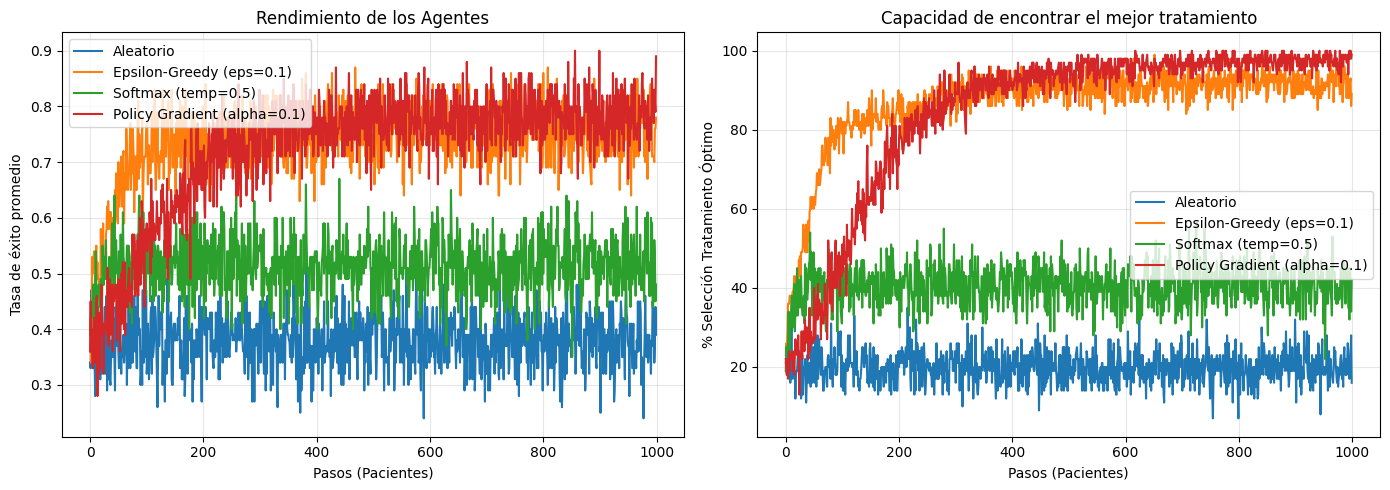

In [9]:
# Visualización de Resultados
plt.figure(figsize=(18, 5))

# Gráfica 1: Recompensa Promedio
plt.subplot(1, 3, 1)
for name, data in results.items():
    plt.plot(data, label=name)
plt.xlabel("Pasos (Pacientes)")
plt.ylabel("Tasa de éxito promedio")
plt.title("Rendimiento de los Agentes")
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica 2: % Acción Óptima
plt.subplot(1, 3, 2)
for name, data in optimal_action_counts.items():
    plt.plot(data * 100, label=name)
plt.xlabel("Pasos (Pacientes)")
plt.ylabel("% Selección Tratamiento Óptimo")
plt.title("Capacidad de encontrar el mejor tratamiento")
plt.legend()
plt.grid(True, alpha=0.3)


# Gráfica 3: Regret Acumulado
plt.subplot(1, 3, 3)
for name, data in regrets.items():
    plt.plot(data, label=name)
plt.xlabel("Pasos (Pacientes)")
plt.ylabel("Regret Acumulado")
plt.title("Regret Acumulado (Menor es mejor)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Análisis y Conclusiones

### Observaciones clave

1.  **Agente Aleatorio**: Se mantiene constante alrededor del promedio de todas las probabilidades de éxito. No aprende nada, por lo que su rendimiento es pobre.
2.  **Epsilon-Greedy**: Aprende rápidamente cuál es la mejor opción, pero debido al parámetro `epsilon`, nunca deja de explorar (sigue eligiendo acciones al azar un 10% del tiempo). Esto le impide alcanzar el 100% de convergencia a la acción óptima, pero asegura un buen rendimiento general rápido.
3.  **Softmax**: Muestra una curva de aprendizaje más suave y estable. Al principio explora mucho, pero a medida que las diferencias de valor se hacen evidentes, converge hacia la mejor opción. Dependiendo de la temperatura, puede converger mejor que epsilon-greedy a largo plazo.
4.  **Policy Gradient**: Puede tardar un poco más en arrancar que Epsilon-Greedy, pero tiene la capacidad de converger casi al 100% a la acción óptima si los parámetros son adecuados, ya que suaviza la política hasta hacerla determinista hacia la mejor opción.

### Conclusión para Salud

En un contexto médico, **minimizan el 'arrepentimiento' (tratamientos fallidos)** es crucial.

- Si necesitamos resultados **rápidos** (ej. una epidemia), **Epsilon-Greedy** es efectivo.
- Si queremos **refinar** la política a largo plazo y estamos dispuestos a asumir cierta exploración inicial controlada, **Softmax** o **Policy Gradient** son ideales porque se adaptan mejor a la incertidumbre relativa entre tratamientos similares.
- El **Policy Gradient** es especialmente útil si quisieramos extender esto a situaciones donde el 'estado' del paciente (edad, síntomas) importa, ya que escala naturalmente a redes neuronales (Deep RL).